# **HAIO Országos Döntő 2024**

**Versenyző neve:**

# Tasks

**Task 1 - Data visualization (x points)**

Examine whether genres can be distinguished at all based on spectrograms: plot the spectrogram of each input belonging to the class for each music genre in the dataset on a common diagram, indicating the music genre in each case.

**Task 2 - Classification with a convolutional network (x points)**

Train a convolutional network from scratch to classify music genres based on spectrograms, achieve at least 75% accuracy on the given test set, check that you achieve this. Briefly describe what settings (image transformations, optimizer, learning rate, etc.) you used to achieve your result.

**3. Task - Augmentation (x points)**

Train the same convolutional model as in Task 2, but this time use data augmentation. Most of the standard image augmentation techniques are unlikely to be applicable here, as they break the temporal correlations in the music. Instead, use any of the augmentation methods proposed in [Park et al, 2019](https://arxiv.org/pdf/1904.08779). See if this yields better accuracy on the test set than before, along with any other tuning changes - briefly summarize them, if any.

**4. Task - Transfer Learning (x points)**

Although natural images differ from the spectrogram images examined here, transfer learning can still be successfully performed with models trained on image data, according to the article [Palanisamy et al., 2020](https://arxiv.org/pdf/2007.11154). Load the DenseNet or Resnet network architecture used in the article with weights pretrained on Imagenet, and fine-tune the network for the music classification task, compare it, and see if better results can be achieved, of course with necessary setting changes.

**5. Task - Clustering (x points)**

Instead of classification, use the neural network trained in the previous task to extract useful feature vectors --- these should be the inputs of the last dense layer ---, represent these projected into 2 dimensions and show in a diagram how much grouping by music genre is observable - for this, display the vectors belonging to each music genre with the same color.

**6. Task - Similarity (x points)**

Quantify how similar the music genres are: calculate the cosine similarity between the feature vectors of samples belonging to different genres, perhaps suggest a more suitable similarity measure for this.

**7. Task - Integrated Gradients (x points)**

Using the integrated gradients method introduced in [Sundararajan et al., 2017](https://proceedings.mlr.press/v70/sundararajan17a/sundararajan17a.pdf) and also used in [Palanisamy et al., 2020](https://arxiv.org/pdf/2007.11154), display what the network detects on an arbitrarily chosen test-set image. Show the original image input and the integrated gradient visualization next to it.

**Task 8 - Vision Transformer training (x points)**

Train or fine-tune the [Vision Transformer](https://arxiv.org/abs/2010.11929) model to the same level as the CNN in task 2, and try to achieve better classification accuracy with it.

**Task 9 - Generation (x points)**

Train or fine-tune a generative model on the spectrograms and generate some completely new spectrograms with it, then convert these back to audio so we can hear how enjoyable the music you generated is.

---
# Prep

In [1]:
# # @title Szükséges könyvtárak betöltése
# !sudo apt-get install -y ffmpeg --quiet
# !pip install librosa --quiet
# !pip install imageio --quiet
# !pip install imageio-ffmpeg --quiet

In [2]:
import os
import glob
import imageio
import random, shutil
import torch
import torch.nn as nn
from tqdm.notebook import tqdm
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display
import librosa
import librosa.display

### Downloading the GTZAN dataset

The GTZAN dataset, which we will use to classify musical styluses, can be downloaded in compressed form from here: [dataset link](https://osf.io/drjhb/download).
Running the code below will automatically download the dataset from the given link and extract it into a folder called Data, within which the spectrograms are organized into separate folders by category in the 'images_original' folder as image files. You can check this by clicking on the (Files) icon at the bottom of the left-hand menu, which will allow you to browse the files available in the current runtime environment.

In [3]:
# import requests

# fname = "music.zip"
# url = "https://osf.io/drjhb/download"
# #url = "https://drive.usercontent.google.com/download?id=1HGuf-lVUrDg8WvBLXTFs1hUX4hNQHutx&export=download&authuser=0"

# if not os.path.isfile(fname):
#     try:
#         r = requests.get(url)
#     except requests.ConnectionError:
#         print("!!! Failed to download data !!!")
#     else:
#         if r.status_code != requests.codes.ok:
#             print("!!! Failed to download data !!!")
#         else:
#             with open(fname, "wb") as fid:
#                 fid.write(r.content)

In [4]:
# from zipfile import ZipFile

# with ZipFile(fname, 'r') as zipObj:
#     # Extract all the contents of zip file in different directory
#     zipObj.extractall()

### Loading the data

First, load and plot an audio file. From this, we will generate the corresponding "mel"-scale spectrogram --- you can read about this process [here](https://towardsdatascience.com/seeing-is-believing-converting-audio-data-into-images-5ed1a2ca6647) --- and compare it to the spectrogram provided in the dataset.

In [5]:
# Inspect an audio file from the dataset.

sample_path = 'Data/genres_original/jazz/jazz.00000.wav'

# if you want to listen to the audio, uncomment below.
display.Audio(sample_path)

y: [-0.00924683 -0.01177979 -0.01370239 ...  0.0071106   0.00561523
  0.00561523] 

y shape: (661794,) 

Sample rate (KHz): 22050 

Length of audio: 30.013333333333332


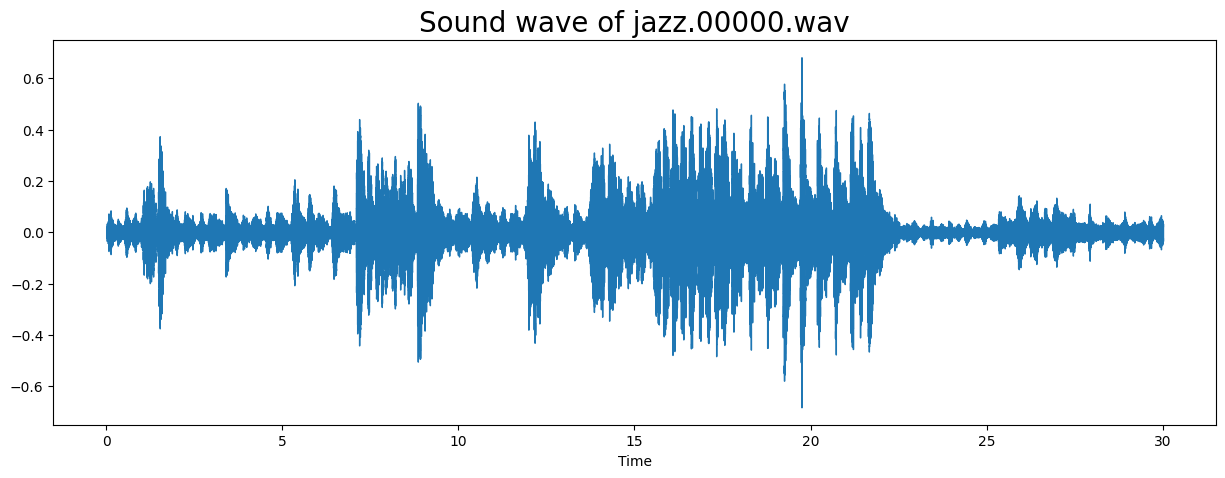

In [6]:
y, sample_rate = librosa.load(sample_path)

print('y:', y, '\n')
print('y shape:', np.shape(y), '\n')
print('Sample rate (KHz):', sample_rate, '\n')
print(f'Length of audio: {np.shape(y)[0]/sample_rate}')

# Plot th sound wave.

plt.figure(figsize=(15, 5))
librosa.display.waveshow(y=y, sr=sample_rate)
plt.title("Sound wave of jazz.00000.wav", fontsize=20)
plt.show()

Shape of D object: (1025, 1293)


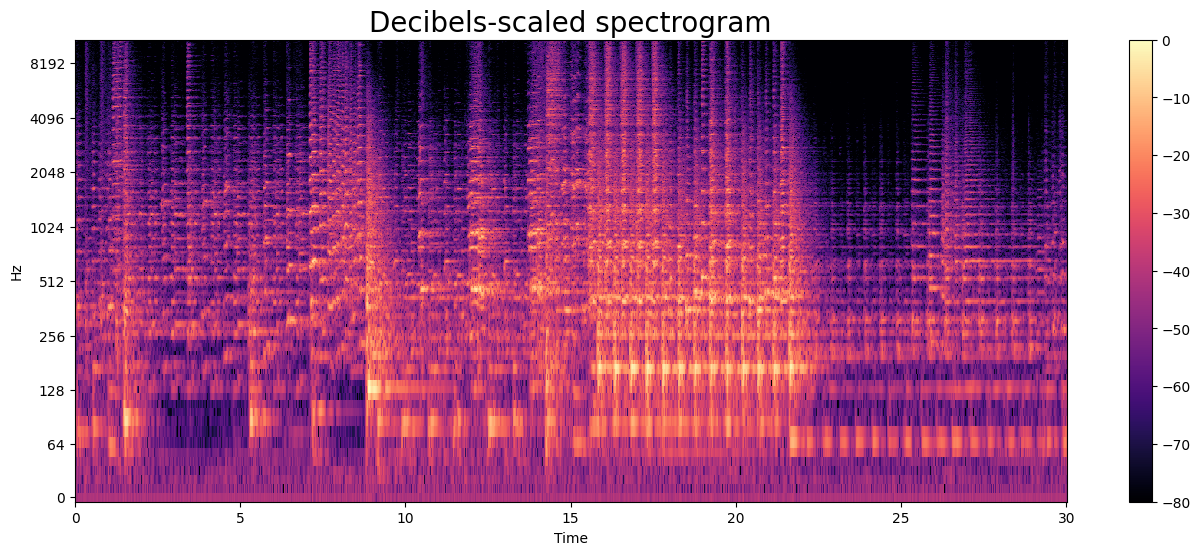

In [7]:
# Convert sound wave to spectrogram.

# Short-time Fourier transform (STFT).

D = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
print('Shape of D object:', np.shape(D))

# Convert amplitude spectrogram to Decibels-scaled spectrogram.

DB = librosa.amplitude_to_db(D, ref = np.max)

# Creating the spectogram.

plt.figure(figsize = (16, 6))
librosa.display.specshow(DB, sr=sample_rate, hop_length=512,
                         x_axis='time', y_axis='log')
plt.colorbar()
plt.title('Decibels-scaled spectrogram', fontsize=20)
plt.show()

A mel scale spectrogram uses a mel scale instead of a linear scale: [you can read about it here](https://en.wikipedia.org/wiki/Mel_scale). In short, the mel scale is a perceptual scale of pitches that we perceive as being equidistant from each other - so it is more in line with how we humans hear sound.

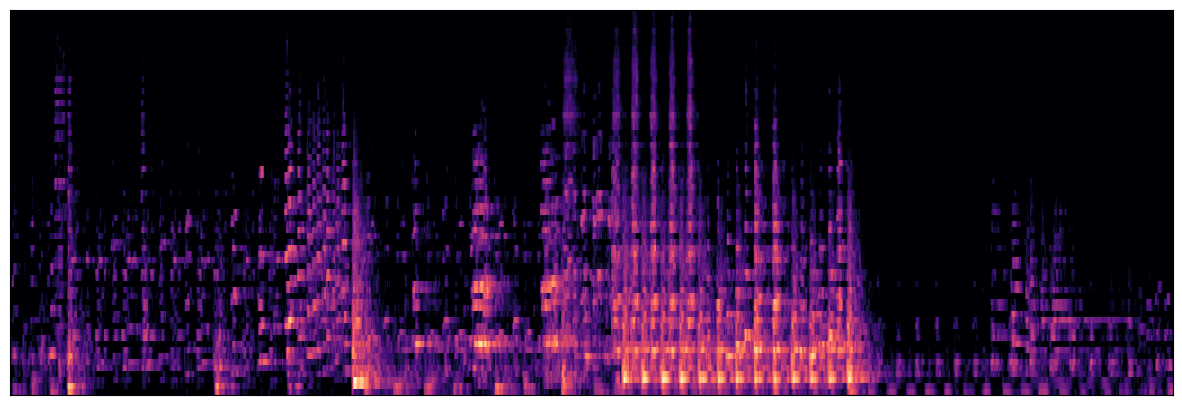

In [8]:
# Convert sound wave to mel spectrogram.

y, sr = librosa.load(sample_path)

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64) #(y, sr=sr)
S_DB = librosa.amplitude_to_db(S, ref=np.max)
plt.figure(figsize=(15, 5))
librosa.display.specshow(S_DB, sr=sr, hop_length=512)# , x_axis='time', y_axis='linear')
#plt.colorbar()
#plt.title("Mel spectrogram", fontsize=20)
plt.show()

(288, 432, 4)


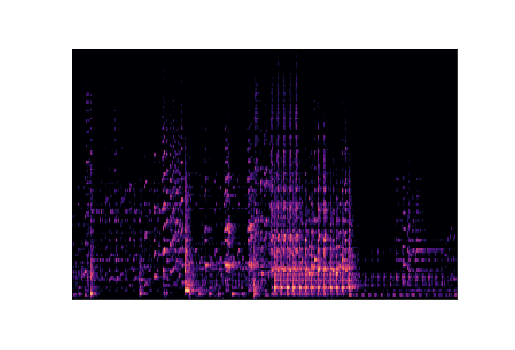

In [9]:
# Visualize the mel spectrogram of the same sample from the dataset.

img_path = 'Data/images_original/jazz/jazz00000.png'
img = imageio.v2.imread(img_path)
print(img.shape)

plt.imshow(img, interpolation='nearest')
plt.axis('off')

# Remove the borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.savefig("./test_image.png", bbox_inches='tight', pad_inches=0)
plt.show()

Note: If we look closely at our images, they have a frame of white pixels, which could potentially make it difficult to train models trained for classification tasks, but we'll leave this issue aside, we don't need to worry about it.

### Tanító és teszt adatok

In [10]:
# Create folder with training, and test data.

spectrograms_dir = "Data/images_original/"
folder_names = ['Data/train/', 'Data/test/']
train_dir = folder_names[0]
test_dir = folder_names[1]

for f in folder_names:
    if os.path.exists(f):
        shutil.rmtree(f)
        os.mkdir(f)
    else:
        os.mkdir(f)

# Loop over all genres.

genres = list(os.listdir(spectrograms_dir))
for g in genres:
    # find all images & split in train and test sets
    src_file_paths= []
    for im in glob.glob(os.path.join(spectrograms_dir, f'{g}',"*.png"), recursive=True):
        src_file_paths.append(im)
    random.shuffle(src_file_paths)
    test_files = src_file_paths[0:20]
    train_files = src_file_paths[20:]

    #  make destination folders for train and test images
    for f in folder_names:
        if not os.path.exists(os.path.join(f + f"{g}")):
            os.mkdir(os.path.join(f + f"{g}"))

    # copy training and testing images over
    for f in train_files:
        shutil.copy(f, os.path.join(os.path.join(train_dir + f"{g}") + '/',os.path.split(f)[1]))
    for f in test_files:
        shutil.copy(f, os.path.join(os.path.join(test_dir + f"{g}") + '/',os.path.split(f)[1]))

In [11]:
# Data loading.

train_dataset = datasets.ImageFolder(
    train_dir,
    transforms.Compose([
        transforms.ToTensor(),
    ]))

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=25, shuffle=True, num_workers=0)

test_dataset = datasets.ImageFolder(
    test_dir,
    transforms.Compose([
        transforms.ToTensor(),
    ]))

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=25, shuffle=True, num_workers=0)

In [12]:
def set_device():
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
      print("WARNING: For this notebook to perform best, "
            "if possible, in the menu under `Runtime` -> "
            "`Change runtime type.`  select `GPU` ")
  else:
      print("GPU is enabled in this notebook.")

  return device


def plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc):
    epochs = len(train_loss)
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(list(range(epochs)), train_loss, label='Training Loss')
    ax1.plot(list(range(epochs)), validation_loss, label='Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Epoch vs Loss')
    ax1.legend()

    ax2.plot(list(range(epochs)), train_acc, label='Training Accuracy')
    ax2.plot(list(range(epochs)), validation_acc, label='Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Epoch vs Accuracy')
    ax2.legend()
    fig.set_size_inches(15.5, 5.5)
    plt.show()

In [13]:
device = set_device()

GPU is enabled in this notebook.


In [14]:

# class music_net(nn.Module):
#   def __init__(self):
#     """Intitalize neural net layers"""
#     super(music_net, self).__init__()
#     self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=0)
#     self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=0)
#     self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=0)
#     self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=0)
#     self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=0)
#     self.fc1 = nn.Linear(in_features=9856, out_features=10)

#     self.batchnorm1 = nn.BatchNorm2d(num_features=8)
#     self.batchnorm2 = nn.BatchNorm2d(num_features=16)
#     self.batchnorm3 = nn.BatchNorm2d(num_features=32)
#     self.batchnorm4 = nn.BatchNorm2d(num_features=64)
#     self.batchnorm5 = nn.BatchNorm2d(num_features=128)

#     self.dropout = nn.Dropout(p=0.3, inplace=False)


#   def forward(self, x):
#     # Conv layer 1.
#     x = self.conv1(x)
#     x = self.batchnorm1(x)
#     x = F.relu(x)
#     x = F.max_pool2d(x, kernel_size=2)

#     # Conv layer 2.
#     x = self.conv2(x)
#     x = self.batchnorm2(x)
#     x = F.relu(x)
#     x = F.max_pool2d(x, kernel_size=2)

#     # Conv layer 3.
#     x = self.conv3(x)
#     x = self.batchnorm3(x)
#     x = F.relu(x)
#     x = F.max_pool2d(x, kernel_size=2)

#     # Conv layer 4.
#     x = self.conv4(x)
#     x = self.batchnorm4(x)
#     x = F.relu(x)
#     x = F.max_pool2d(x, kernel_size=2)

#     # Conv layer 5.
#     x = self.conv5(x)
#     x = self.batchnorm5(x)
#     x = F.relu(x)
#     x = F.max_pool2d(x, kernel_size=2)

#     # Fully connected layer 1.
#     x = torch.flatten(x, 1)
#     x = self.dropout(x)
#     x = self.fc1(x)
#     x = F.softmax(x, dim=-1)

#     return x

In [15]:
def plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc):
    """Tanitas es validacio loss/accuracy gorbeinek abrazolasa."""
    epochs = len(train_loss)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(range(epochs), train_loss, label='Tanitasi Loss')
    ax1.plot(range(epochs), validation_loss, label='Validacios Loss')
    ax1.set_xlabel('Epocha')
    ax1.set_ylabel('Loss')
    ax1.set_title('Epocha vs Loss')
    ax1.legend()

    ax2.plot(range(epochs), train_acc, label='Tanitasi Pontossag')
    ax2.plot(range(epochs), validation_acc, label='Validacios Pontossag')
    ax2.set_xlabel('Epocha')
    ax2.set_ylabel('Pontossag')
    ax2.set_title('Epocha vs Pontossag')
    ax2.legend()
    plt.tight_layout()
    plt.show()


def evaluate(model, data_loader, device):
    """Modell kiertekelese egy adott adathalmazon."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return correct / total


def train_model(model, device, train_loader, test_loader, epochs, lr=0.001):
    """Altalanos tanitasi ciklus loss es accuracy nyomonkovetesevel."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in tqdm(range(epochs), desc='Tanitas'):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(output, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

        train_loss_hist.append(running_loss / len(train_loader))
        train_acc_hist.append(correct / total)

        # Validacio
        model.eval()
        running_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                running_loss += loss.item()
                _, predicted = torch.max(output, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        val_loss_hist.append(running_loss / len(test_loader))
        val_acc_hist.append(correct / total)

        if (epoch + 1) % 10 == 0:
            print(f'Epocha {epoch+1}/{epochs} - '
                  f'Train Loss: {train_loss_hist[-1]:.4f}, Train Acc: {train_acc_hist[-1]:.4f}, '
                  f'Val Loss: {val_loss_hist[-1]:.4f}, Val Acc: {val_acc_hist[-1]:.4f}')

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

In [ ]:
# # Run training.

# net = music_net().to(device)
# train_loss, train_acc, validation_loss, validation_acc = train(net, device, train_loader, test_loader, 30)

# # Detach tensors from GPU
# plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

NameError: name 'music_net' is not defined

# **1\. Task - Data Visualization (x points)**

Examine whether genres can be distinguished at all based on spectrograms: plot the spectrogram of each input belonging to the class for each music genre in the data set on a common diagram, indicating the music genre in each case.

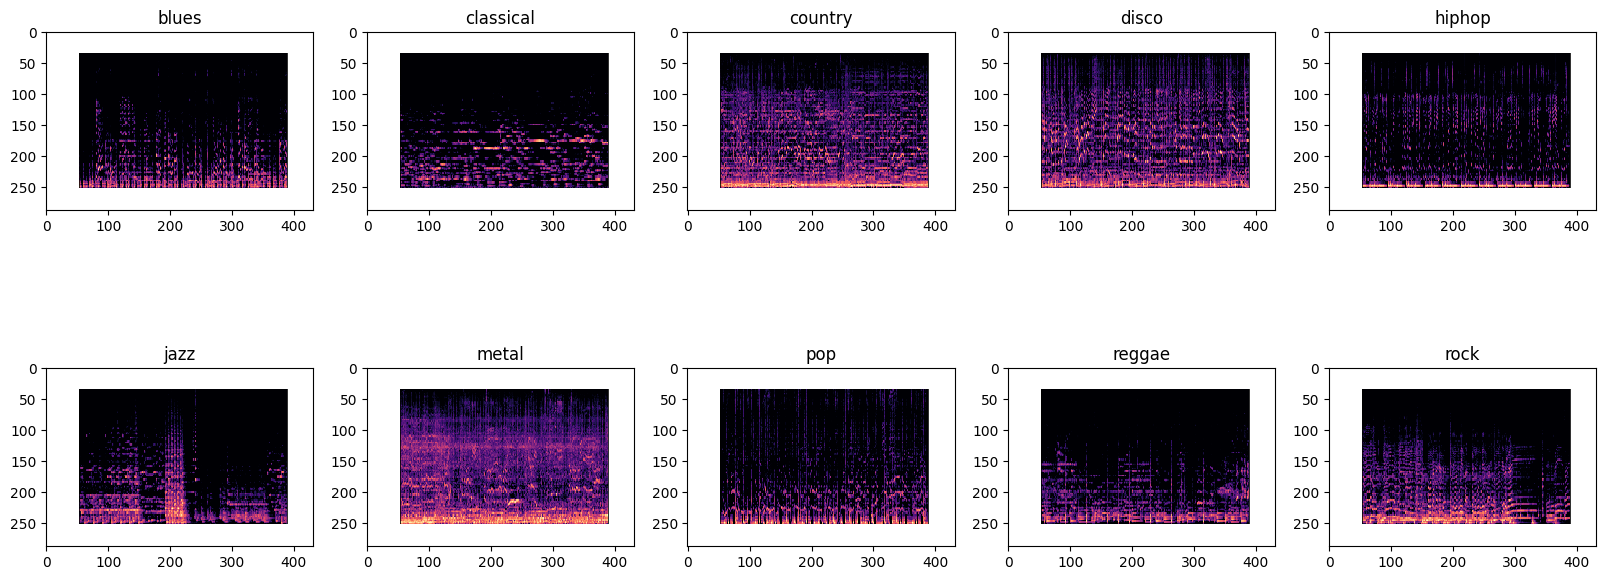

In [18]:
genres = list(os.listdir(spectrograms_dir))
fig, ax = plt.subplots(ncols=len(genres)//2, nrows=2)
ax = ax.flatten()
fig.set_size_inches(20, 8)
for i, genre in enumerate(genres):
    img_path = os.path.join(spectrograms_dir, genre, f'{genre}00001.png')
    img = imageio.v2.imread(img_path)

    ax[i].imshow(img, interpolation='nearest')
    ax[i].set_title(genre)

# **2\. Task - Classification with a convolutional network (x points)**

Train a convolutional network from scratch to classify music genres based on spectrograms, achieve at least 75% accuracy on the given test set, check that you achieve this. Briefly describe what settings (image transformations, optimizer, learning rate, etc.) you used to achieve your result.

In [19]:
class AudioCRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.gru = nn.GRU(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            dropout=0.2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.cnn(x)              # (B, C, T', F')
        x = x.mean(dim=-1)          # collapse frequency → (B, C, T')
        x = x.permute(0, 2, 1)      # (B, T', C)
        _, h = self.gru(x)
        return self.fc(h[-1])
     

# CNN tanitasa
cnn_model = AudioCRNN(10).to(device)
print(f'Parameterek szama: {sum(p.numel() for p in cnn_model.parameters()):,}')

cnn_train_loss, cnn_train_acc, cnn_val_loss, cnn_val_acc = train_model(
    cnn_model, device, train_loader, test_loader, epochs=50, lr=0.001
)

plot_loss_accuracy(cnn_train_loss, cnn_train_acc, cnn_val_loss, cnn_val_acc)

cnn_test_acc = evaluate(cnn_model, test_loader, device)
print(f'\nCNN teszt pontossag: {cnn_test_acc:.4f} ({cnn_test_acc*100:.1f}%)')
     


Parameterek szama: 2,364,170


Tanitas:   0%|          | 0/50 [00:00<?, ?it/s]

Epocha 10/50 - Train Loss: 1.3564, Train Acc: 0.5031, Val Loss: 1.7719, Val Acc: 0.4200
Epocha 20/50 - Train Loss: 0.9472, Train Acc: 0.6508, Val Loss: 1.4341, Val Acc: 0.5650
Epocha 30/50 - Train Loss: 0.6835, Train Acc: 0.7522, Val Loss: 1.1469, Val Acc: 0.6400


KeyboardInterrupt: 

# **3\. Task - Augmentation (x points)**

Train the same convolutional model as in Task 2, but this time use data augmentation. Most of the standard image augmentation techniques are probably not applicable here, as they break the temporal correlations in the music. Instead, use any of the augmentation methods proposed in [Park et al, 2019](https://arxiv.org/pdf/1904.08779). See if this yields better accuracy on the test set than before, along with any other tuning changes - briefly summarize them, if any.



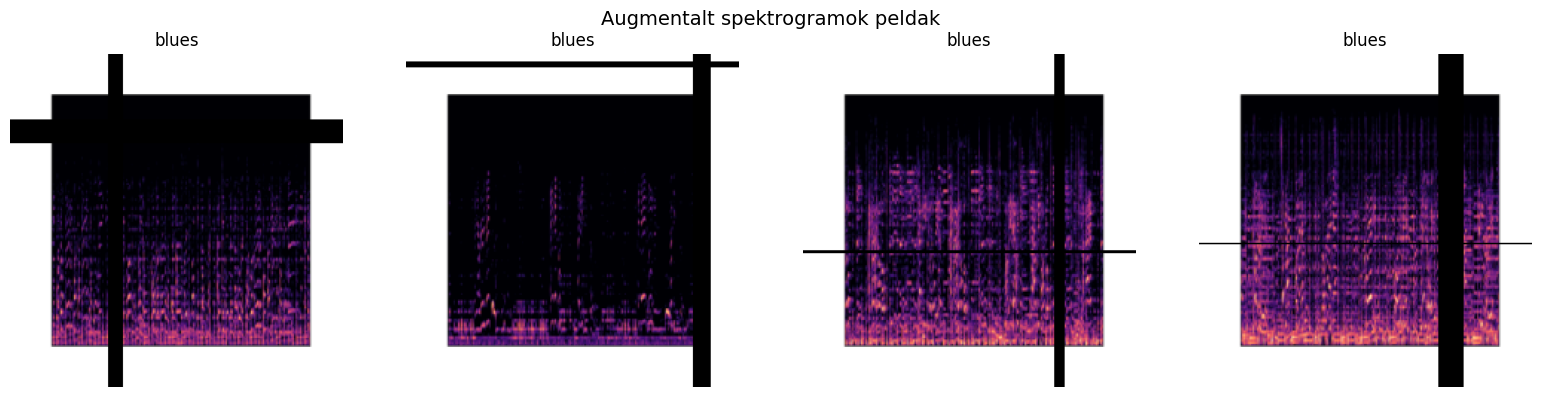

In [ ]:
from torch.utils.data import DataLoader
IMG_SIZE = 224

class FrequencyMasking:
    def __init__(self, freq_mask_param = 20):
        self.freq_mask_param = freq_mask_param

    def __call__(self, img):
        c, h, w = img.shape
        f = np.random.randint(0, self.freq_mask_param)
        f0 = np.random.randint(0, h-f)
        img[:, f0:f0+f, :] = 0
        return img
    
class TimeMasking:
    def __init__(self, time_mask_param = 20):
        self.time_mask_param = time_mask_param

    def __call__(self, img):
        c, h, w = img.shape
        t = np.random.randint(0, self.time_mask_param)
        t0 = np.random.randint(0, w-t)
        img[:, :, t0:t0+t] = 0
        return img
    
augmented_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    FrequencyMasking(),
    TimeMasking()
])

aug_train_dataset = datasets.ImageFolder(train_dir, transform=augmented_transform)
aug_train_loader = DataLoader(aug_train_dataset, batch_size=25, shuffle=True, num_workers=0)

# Vizualizaljuk az augmentalt kepeket
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Augmentalt spektrogramok peldak', fontsize=14)
for i in range(4):
    img, label = aug_train_dataset[i * 20]
    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(genres[label])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# **4\. Task - Transfer learning (x points)**

Although natural images differ from the spectrogram images examined here, transfer learning can nevertheless be successfully performed with models trained on image data according to the article [Palanisamy et al., 2020](https://arxiv.org/pdf/2007.11154). Load the DenseNet or Resnet network architecture used in the article with weights pretrained on Imagenet, and fine-tune the network for the music classification task, compare it, and see if better results can be achieved, of course with necessary setting changes.

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
resnet_model = resnet50(ResNet50_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model = resnet_model.to(device)

imagenet_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

imagenet_train_dataset = datasets.ImageFolder(train_dir, transform=imagenet_transform)
imagenet_test_dataset = datasets.ImageFolder(test_dir, transform=imagenet_transform)
imagenet_train_loader = DataLoader(imagenet_train_dataset, batch_size=25, shuffle=True, num_workers=0)
imagenet_test_loader = DataLoader(imagenet_test_dataset, batch_size=25, shuffle=False, num_workers=0)

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Tanitas:   0%|          | 0/5 [00:00<?, ?it/s]

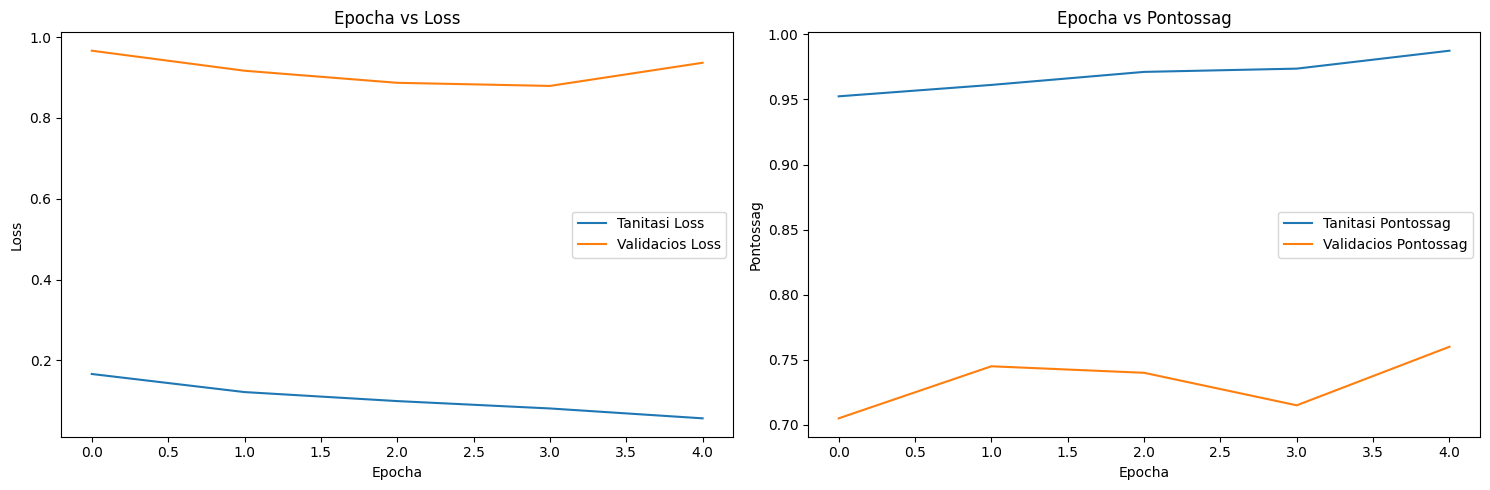


DenseNet121 teszt pontossag: 0.7600 (76.0%)
CNN (nullarol) teszt pontossag: 0.6000 (60.0%)
A transzfer tanulas jellemzoen jobb eredmenyt ad, mivel az ImageNet elotanitas
hasznos vizualis jellemzoket tanult, amelyek a spektrogramokra is alkalmazhatok.


In [ ]:
dn_train_loss, dn_train_acc, dn_val_loss, dn_val_acc = train_model(
    resnet_model, device, imagenet_train_loader, imagenet_test_loader, epochs=5, lr=0.0001
)

plot_loss_accuracy(dn_train_loss, dn_train_acc, dn_val_loss, dn_val_acc)

dn_test_acc = evaluate(resnet_model, imagenet_test_loader, device)
print(f'\nDenseNet121 teszt pontossag: {dn_test_acc:.4f} ({dn_test_acc*100:.1f}%)')
print(f'CNN (nullarol) teszt pontossag: {cnn_test_acc:.4f} ({cnn_test_acc*100:.1f}%)')
print(f'A transzfer tanulas jellemzoen jobb eredmenyt ad, mivel az ImageNet elotanitas')
print(f'hasznos vizualis jellemzoket tanult, amelyek a spektrogramokra is alkalmazhatok.')

# **5. Task - Clustering (x points)**

Instead of classification, use the neural network trained in the previous task to extract useful feature vectors --- these should be the inputs of the last dense layer ---, represent these projected into 2 dimensions and show in a diagram how observable the clustering by music genre is - to do this, display the vectors belonging to each music genre in the same color.

In [ ]:
imagenet_train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = input[0].detach()
    return hook

hook_handle = resnet_model.fc.register_forward_hook(get_activation('features'))

# nn.Identity()


features_list = []
labels_list = []
train_features_list = []
train_labels_list = []

resnet_model.eval()
with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        _ = resnet_model(data)
        features_list.append(activation['features'].cpu().numpy())
        labels_list.append(label.numpy())

    for data, target in imagenet_train_loader:
        data = data.to(device)
        _ = resnet_model(data)
        train_features_list.append(activation['features'].cpu().numpy())
        train_labels_list.append(target.numpy())

hook_handle.remove()

all_features = np.concatenate(features_list + train_features_list, axis=0)
all_labels = np.concatenate(labels_list + train_labels_list, axis=0)

test_features = np.concatenate(features_list, axis=0)
test_labels = np.concatenate(labels_list, axis=0)

In [ ]:
res.shape

(999, 2)

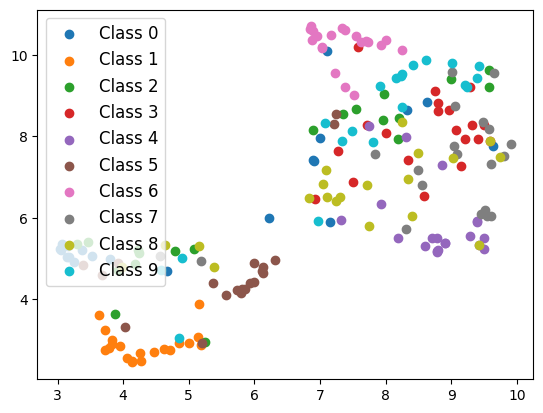

In [ ]:
from umap import UMAP
u_map = UMAP(n_components=2)
res = u_map.fit_transform(test_features)

for label in np.unique(test_labels):
    plt.scatter(
        res[test_labels == label, 0],
        res[test_labels == label, 1],
        label=f"Class {label}"
    )

plt.legend(fontsize=12)
plt.show()

#**6\. Task - Similarity (x points)**

Quantify how similar the music genres are: calculate the cosine similarity between the feature vectors of samples belonging to different genres, perhaps suggesting a more suitable similarity measure for this.

<Axes: >

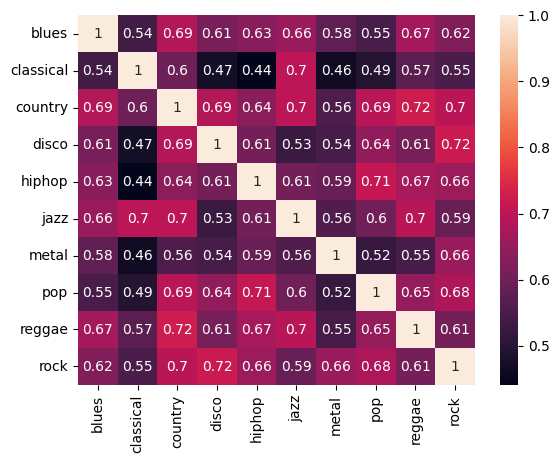

In [ ]:
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

centroids = []
for i in range(10):
    mask = all_labels == i
    centroids.append(all_features[mask].mean(axis=0))

sim_matrix = cosine_similarity(centroids)
sns.heatmap(sim_matrix, xticklabels=genres, yticklabels=genres, annot=True)

#**7\. Task - Integrated Gradients (x points)**

Using the integrated gradients method introduced in [Sundararajan et al., 2017](https://proceedings.mlr.press/v70/sundararajan17a/sundararajan17a.pdf) and also used in [Palanisamy et al., 2020](https://arxiv.org/pdf/2007.11154), display what the network detects on an arbitrary test-set image. Show the original image input and the integrated gradient visualization next to it.


# **8\. Feladat - Vision Transformer tanítás (x pont)**

  Taníts vagy finomhangolj [Vision Transformer](https://arxiv.org/abs/2010.11929) modellt ugyanarra mint a 2. feladatban a CNN-t, próbálj jobb klasszifikációs pontosságot elérni vele.


In [ ]:
import timm

vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=10)
vit_model = vit_model.to(device)

print(f'ViT parameterek szama: {sum(p.numel() for p in vit_model.parameters()):,}')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\raian\.cache\huggingface\hub\models--timm--vit_base_patch16_224.augreg2_in21k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ViT parameterek szama: 85,806,346


In [ ]:
vit_train_loss, vit_train_acc, vit_val_loss, vit_val_acc = train_model(
    vit_model, device, imagenet_train_loader, imagenet_test_loader, epochs=5, lr=0.00005
)

plot_loss_accuracy(vit_train_loss, vit_train_acc, vit_val_loss, vit_val_acc)

vit_test_acc = evaluate(vit_model, imagenet_test_loader, device)
print(f'\n--- Osszehasonlitas ---')
print(f'DenseNet121 (tl):    {dn_test_acc*100:.1f}%')
print(f'Vision Transformer:  {vit_test_acc*100:.1f}%')

Tanitas:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 


# **9\. Feladat - Generálás (x pont)**

  Taníts vagy finomhangolj egy generatív modellt a spektrogramokon, és generáld le vele néhány teljesen új spetrogramot, ezeket alakítsd vissza audióvá, heogy meghallgathassuk, mennyire élvezhető az általad generált zene.

In [ ]:
# VAE architektura
class VAE(nn.Module):
    """Variational Autoencoder spektrogramokhoz."""
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # 224 -> 112
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 112 -> 56
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 56 -> 28
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 28 -> 14
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        
        # Latens ter: mu es logvar
        self.fc_mu = nn.Linear(256 * 14 * 14, latent_dim)
        self.fc_logvar = nn.Linear(256 * 14 * 14, latent_dim)
        
        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 256 * 14 * 14)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # 14 -> 28
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 28 -> 56
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 56 -> 112
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),    # 112 -> 224
            nn.Sigmoid(),
        )
    
    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        """Reparametrizacios trukk: z = mu + sigma * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, 14, 14)
        return self.decoder(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon_x, x, mu, logvar):
    """VAE veszteségfüggvény: rekonstrukcios hiba + KL divergencia."""
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss